# MDBench 预实验结果审计（2026-09-01）

这份 notebook 回答三个问题：Benchmark 被解决到什么程度、是否太简单、以及高分是否等价于真正的机制发现。

**先给结论：当前系统几乎解决了“无噪声数据 → 唯象方程”，但远未可靠解决“数据 → 基础机制 DAG”。** GPT-5.6-sol / DeepSeek 的 OOD 预测成功率约为 98.6% / 95.6%，而要求 OOD 预测过线且参考结构恢复 ≥0.9 时仅约 15.9% / 5.9%。这不是单纯的“题太容易”：可观测公式部分偏容易，隐藏机制部分则存在不可辨识性、参考答案非唯一和评价错位。下面的数字均由本 notebook 从 `logs/mdbench` 重算。两个日志目录的清单是 69 runs/18 家族与 68 runs/17 家族，并非严格逐题配对，因此模型间数字只作描述性比较，不解释为受控 head-to-head 排名。

In [1]:
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import sympy as sp
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid', context='notebook')

# Matplotlib 默认 DejaVu Sans 不含中文字形；显式注册并使用仓库运行环境中的 CJK 字体。
cjk_font_name = None
for font_path in [
    Path('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'),
    Path('/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf'),
]:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        cjk_font_name = font_manager.FontProperties(fname=str(font_path)).get_name()
        break
if cjk_font_name is None:
    for candidate in ['Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei', 'PingFang SC']:
        try:
            font_manager.findfont(candidate, fallback_to_default=False)
            cjk_font_name = candidate
            break
        except ValueError:
            pass
if cjk_font_name:
    plt.rcParams.update({'font.family': cjk_font_name, 'axes.unicode_minus': False})
else:
    warnings.warn('未找到中文字体，图中的中文可能显示为方框。')
print('Matplotlib CJK font:', cjk_font_name)

def find_repo_root(start=Path.cwd()):
    for p in (start, *start.parents):
        if (p / 'logs' / 'mdbench').is_dir():
            return p
    raise FileNotFoundError('找不到 logs/mdbench；请从仓库内运行 notebook')

ROOT = find_repo_root()
LOG_ROOT = ROOT / 'logs' / 'mdbench'
print('repo:', ROOT)


Matplotlib CJK font: Noto Sans CJK JP
repo: /mnt/mergerfs/yuzihan/MergedWorkSpace/45-MechanismDiscoveryBench/MechanismDiscoveryBench


## 1. 解析最终评测

将“解决”拆成四层，避免一个总分掩盖任务性质：

1. `predictive_solved`：OOD R² ≥ 0.99 且 tolerance accuracy ≥ 0.99；
2. `equation_solved`：再要求 derived-equation agreement ≥ 0.99；
3. `mechanism_lenient`：预测过线且参考结构恢复 ≥ 0.8；
4. `mechanism_strict`：预测过线且参考结构恢复 ≥ 0.9。

后两项只是“接近当前单一参考 DAG”，不是机制真理判决；后面会展示它既可能漏判合理替代机制，也可能被模板记忆抬高。

In [2]:
ANSI = re.compile(r'\x1b\[[0-9;]*m')

def parse_triplet(text, label, percent=False):
    suffix = r'%' if percent else ''
    pat = rf'{re.escape(label)}:\s*([-+0-9.eE]+){suffix}\s*\|\s*([-+0-9.eE]+){suffix}\s*\|\s*([-+0-9.eE]+){suffix}'
    match = re.search(pat, text)
    if not match:
        return [np.nan] * 3
    values = [float(x) for x in match.groups()]
    return [x / 100 if percent else x for x in values]

def first_float(text, pattern, scale=1.0):
    match = re.search(pattern, text)
    return float(match.group(1)) * scale if match else np.nan

rows = []
for model_dir in sorted(p for p in LOG_ROOT.iterdir() if p.is_dir()):
    for run_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
        if not (run_dir / 'problem.json').exists():  # 排除“辅助记录”等目录
            continue
        problem = json.loads((run_dir / 'problem.json').read_text())
        answer = json.loads((run_dir / 'answer.json').read_text())
        eval_path = run_dir / 'final_evaluation.txt'
        text = ANSI.sub('', eval_path.read_text(errors='replace')) if eval_path.exists() else ''
        pearson = parse_triplet(text, 'Pearson r')
        r2 = parse_triplet(text, 'R2')
        acc = parse_triplet(text, 'Acc (rtol=1e-6, atol=1e-9)', percent=True)
        fm = re.search(r'formula=([0-9.]+)%,\s*DAG=([0-9.]+)%', text)
        eq = re.search(r'Derived-equation equivalence:\s*([0-9.]+)%\s*\(equivalent=(True|False|None)\)', text)
        cm = re.search(r'mean=([0-9.]+) AST nodes/item, maximum=([0-9]+), total=([0-9]+) across ([0-9]+) relationships', text)
        submission = [x.strip() for x in (run_dir / 'submission.txt').read_text(errors='replace').splitlines() if x.strip()]
        train = np.load(run_dir / 'data_train.npy')
        family = re.sub(r'_(?:Case_\d+|[1-4](?:st|nd|rd|th))$', '', run_dir.name.replace('_-_', '_'))
        rows.append({
            'model': model_dir.name, 'run': run_dir.name, 'family': family, 'path': run_dir,
            'target': problem['target_variable'], 'n_train': train.shape[1],
            'n_inputs': len(problem.get('variables', [])) - 1,
            'n_reference': len(answer.get('mechanisms', [])), 'n_submitted': len(submission),
            'train_r2': r2[0], 'id_r2': r2[1], 'ood_r2': r2[2],
            'train_acc': acc[0], 'id_acc': acc[1], 'ood_acc': acc[2],
            'derived_score': float(eq.group(1))/100 if eq else np.nan,
            'derived_equivalent': eq.group(2) == 'True' if eq else np.nan,
            'structure': first_float(text, r'Ground-truth structure recovery:\s*([0-9.]+)%', .01),
            'formula_structure': float(fm.group(1))/100 if fm else np.nan,
            'dag_structure': float(fm.group(2))/100 if fm else np.nan,
            'fundamentality': first_float(text, r'Mechanism fundamentality score:\s*([0-9.]+)%', .01),
            'fundamentality_unavailable': 'Mechanism fundamentality: unavailable' in text,
            'complexity_total': int(cm.group(3)) if cm else np.nan,
        })

df = pd.DataFrame(rows)
df['predictive_solved'] = (df.ood_r2 >= .99) & (df.ood_acc >= .99)
df['equation_solved'] = df.predictive_solved & (df.derived_score >= .99)
df['mechanism_lenient'] = df.predictive_solved & (df.structure >= .80)
df['mechanism_strict'] = df.predictive_solved & (df.structure >= .90)
display(df.groupby('model').agg(runs=('run','size'), families=('family','nunique'), train_points=('n_train','median')))


,runs,families,train_points
model,,,
codex-deepseek-v4-flash-0731,68,17,1000.0
codex-gpt-5.6-sol,69,18,1000.0


,OOD_R2_mean,OOD_acc_mean,equation_agreement_mean,structure_mean,structure_median,formula_structure_mean,DAG_structure_mean,fundamentality_mean,fundamentality_available
model,,,,,,,,,
codex-deepseek-v4-flash-0731,0.981590,0.985882,0.955647,0.512796,0.50355,0.489522,0.547693,0.806793,68
codex-gpt-5.6-sol,0.999949,0.995246,0.999768,0.671339,0.64820,0.624991,0.740855,NaN,0


,OOD prediction,derived equation,mechanism ≥0.8,mechanism ≥0.9
model,,,,
codex-deepseek-v4-flash-0731,95.6%,94.1%,7.4%,5.9%
codex-gpt-5.6-sol,98.6%,98.6%,23.2%,15.9%


### 精度澄清：均值显示为 1.000 不等于每个 run 都等于 1

,runs,derived_score_exactly_1,equivalent_true,derived_score_mean,OOD_R2_exactly_1,OOD_R2_mean
model,,,,,,
codex-deepseek-v4-flash-0731,68,64,64,0.955647,65,0.981590
codex-gpt-5.6-sol,69,68,68,0.999768,68,0.999949


,run,train_r2,id_r2,ood_r2,ood_acc,derived_score,derived_equivalent
70,Downward_Motion_of_a_Particle_through_a_Fluid_-_3rd,1.0,1.0,0.99648,0.672,0.984,False


**结论：** GPT-5.6-sol 是 68/69 个 run 的 derived score=1 且 equivalent=True；唯一例外的 derived score=0.984、equivalent=False、OOD R²=0.996480。原表将 derived 均值 0.999768 和 OOD R² 均值 0.999949 都舍入成了 1.000。因此这里没有“所有方程严格等价但 OOD 不等于 1”的矛盾。

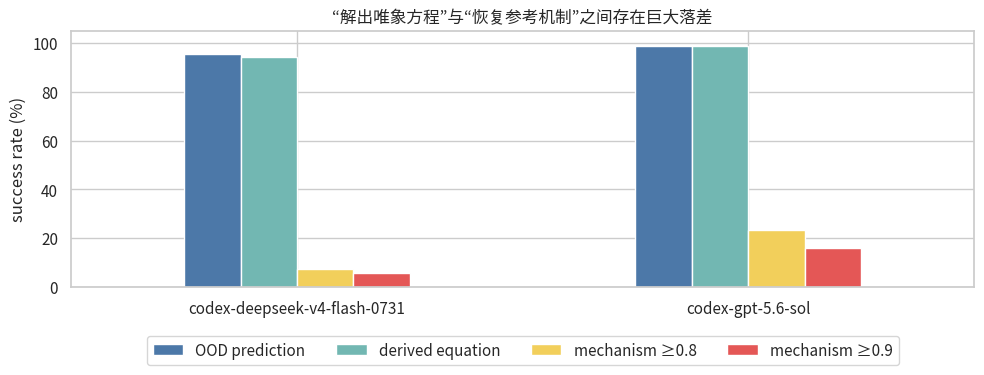

In [3]:
metric_summary = df.groupby('model').agg(
    OOD_R2_mean=('ood_r2','mean'), OOD_acc_mean=('ood_acc','mean'),
    equation_agreement_mean=('derived_score','mean'),
    structure_mean=('structure','mean'), structure_median=('structure','median'),
    formula_structure_mean=('formula_structure','mean'), DAG_structure_mean=('dag_structure','mean'),
    fundamentality_mean=('fundamentality','mean'),
    fundamentality_available=('fundamentality','count'),
).round(6)
success = df.groupby('model')[[
    'predictive_solved','equation_solved','mechanism_lenient','mechanism_strict'
]].mean().rename(columns={
    'predictive_solved':'OOD prediction', 'equation_solved':'derived equation',
    'mechanism_lenient':'mechanism ≥0.8', 'mechanism_strict':'mechanism ≥0.9'
}).round(3)
display(metric_summary)
display((100*success).round(1).astype(str) + '%')

equivalence_audit = df.groupby('model').agg(
    runs=('run','size'),
    derived_score_exactly_1=('derived_score', lambda s: int((s == 1).sum())),
    equivalent_true=('derived_equivalent', lambda s: int((s == True).sum())),
    derived_score_mean=('derived_score','mean'),
    OOD_R2_exactly_1=('ood_r2', lambda s: int((s == 1).sum())),
    OOD_R2_mean=('ood_r2','mean'),
).round(6)
display(Markdown('### 精度澄清：均值显示为 1.000 不等于每个 run 都等于 1'))
display(equivalence_audit)
gpt_exceptions = df[(df.model == 'codex-gpt-5.6-sol') & (
    (df.derived_score < 1) | (df.derived_equivalent != True) | (df.ood_r2 < 1)
)][['run','train_r2','id_r2','ood_r2','ood_acc','derived_score','derived_equivalent']]
display(gpt_exceptions)
display(Markdown(
    '**结论：** GPT-5.6-sol 是 68/69 个 run 的 derived score=1 且 equivalent=True；'
    '唯一例外的 derived score=0.984、equivalent=False、OOD R²=0.996480。'
    '原表将 derived 均值 0.999768 和 OOD R² 均值 0.999949 都舍入成了 1.000。'
    '因此这里没有“所有方程严格等价但 OOD 不等于 1”的矛盾。'
))

ax = (100*success).plot.bar(figsize=(10,4), rot=0, ylim=(0,105), color=['#4c78a8','#72b7b2','#f2cf5b','#e45756'])
ax.set_ylabel('success rate (%)'); ax.set_xlabel('')
ax.set_title('“解出唯象方程”与“恢复参考机制”之间存在巨大落差')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(.5,-.16))
plt.tight_layout(); plt.show()


model,codex-deepseek-v4-flash-0731,codex-gpt-5.6-sol
structure threshold,,
0.50,0.500,0.841
0.60,0.324,0.652
0.70,0.176,0.406
0.80,0.074,0.232
0.90,0.059,0.159
0.95,0.044,0.130


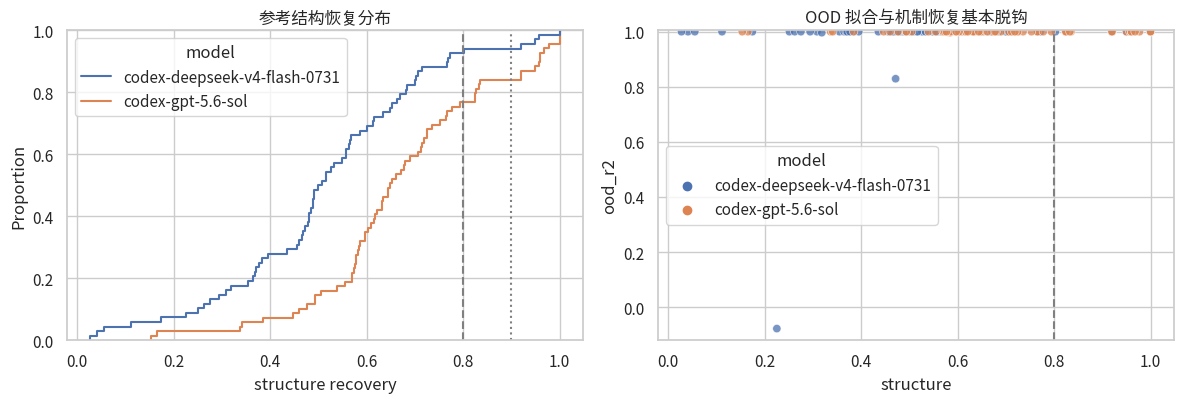

,,ood_r2,derived_score,structure,formula_structure,dag_structure,fundamentality
model,,,,,,,
codex-deepseek-v4-flash-0731,structure,0.17,0.12,1.0,0.92,0.86,0.11
codex-gpt-5.6-sol,structure,0.06,0.06,1.0,0.94,0.86,NaN


In [4]:
thresholds = np.array([.50,.60,.70,.80,.90,.95])
threshold_rows = []
for model, g in df.groupby('model'):
    for t in thresholds:
        threshold_rows.append({'model':model, 'structure threshold':t, 'rate':(g.predictive_solved & (g.structure>=t)).mean()})
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.pivot(index='structure threshold', columns='model', values='rate').round(3))

fig, axes = plt.subplots(1,2,figsize=(12,4.2))
sns.ecdfplot(data=df, x='structure', hue='model', ax=axes[0])
axes[0].axvline(.8, ls='--', color='grey'); axes[0].axvline(.9, ls=':', color='grey')
axes[0].set_title('参考结构恢复分布'); axes[0].set_xlabel('structure recovery')
sns.scatterplot(data=df, x='structure', y='ood_r2', hue='model', alpha=.75, ax=axes[1])
axes[1].set_ylim(min(-.12,df.ood_r2.min()-.02),1.005); axes[1].axvline(.8,ls='--',color='grey')
axes[1].set_title('OOD 拟合与机制恢复基本脱钩')
plt.tight_layout(); plt.show()
display(df.groupby('model')[[
    'ood_r2','derived_score','structure','formula_structure','dag_structure','fundamentality'
]].corr().loc[(slice(None),'structure'),:].round(2))


**解释。** OOD 满分只说明候选方程在同一个生成机制、相邻或扩大参数区间上外推成功。它并不识别隐藏 DAG：任意代数等价分解都会得到相同数据。当前数据本身通常无法区分“参考机制”“另一条物理上合理的推导链”和“把最终公式写成一行”。

In [5]:
family = df.groupby(['model','family']).agg(
    n=('run','size'), prediction=('predictive_solved','mean'), equation=('equation_solved','mean'),
    structure=('structure','mean'), strict=('mechanism_strict','mean')
).reset_index()
for model, table in family.groupby('model'):
    display(Markdown(f'### {model}：逐家族'))
    display(table.drop(columns='model').sort_values('structure').round(3))

suspect = df[df.predictive_solved & (df.structure < .60)][[
    'model','run','ood_r2','ood_acc','derived_score','structure','formula_structure','dag_structure','n_reference','n_submitted'
]].sort_values(['model','structure'])
print(f'预测成功但结构 <0.6：{len(suspect)}/{len(df)} runs')
display(suspect.head(25).round(4))


### codex-deepseek-v4-flash-0731：逐家族

,family,n,prediction,equation,structure,strict
2,Black-Hole_Horizon_Radius,4,1.00,1.00,0.207,0.000
8,Narrow-Tube_Liquid_Rise,4,1.00,1.00,0.416,0.000
4,Compact-Object_Characteristic_Luminosity,4,1.00,1.00,0.429,0.000
1,Atmospheric_Parcel_Stability_Measure,4,1.00,1.00,0.432,0.000
3,Bound-Particle_Orbital_Radius,4,0.75,0.75,0.434,0.000
10,Particle_Settling_Response,4,0.75,0.75,0.451,0.000
14,Settling_Transient_Velocity,6,1.00,1.00,0.492,0.167
9,Orbital_Radial-Velocity_Semi-Amplitude,4,1.00,1.00,0.497,0.000
16,Spring_Oscillator_Period,4,0.75,0.75,0.508,0.000
6,Enzyme_Reaction_Rate,4,1.00,1.00,0.523,0.000


### codex-gpt-5.6-sol：逐家族

,family,n,prediction,equation,structure,strict
33,Rise_of_a_Liquid_in_a_Narrow_Container,4,1.00,1.00,0.409,0.00
22,Motion_of_an_Air_Parcel_in_a_Stratified_Atmosphere,4,1.00,1.00,0.420,0.00
32,Rate_of_an_Enzyme-Catalyzed_Reaction,4,1.00,1.00,0.508,0.00
29,Quantized_Orbital_Motion_around_an_Atomic_Center,4,1.00,1.00,0.532,0.00
25,Oscillation_of_a_Suspended_Mass,4,1.00,1.00,0.593,0.00
26,Outer_Boundary_of_a_Compact_Gravitating_Object,4,1.00,1.00,0.631,0.00
23,Observed_Motion_in_a_Gravitationally_Bound_Stellar_System,4,1.00,1.00,0.636,0.00
19,Motion_of_Two_Masses_Connected_over_a_Pulley,4,1.00,1.00,0.637,0.00
17,Downward_Motion_of_a_Particle_through_a_Fluid,4,0.75,0.75,0.638,0.00
31,Radiative_Heating_of_a_Planetary_Surface,4,1.00,1.00,0.658,0.00


预测成功但结构 <0.6：66/137 runs


,model,run,ood_r2,ood_acc,derived_score,structure,formula_structure,dag_structure,n_reference,n_submitted
11,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_04,1.0,1.0,1.0,0.0273,0.0455,0.0000,5,1
8,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_01,1.0,1.0,1.0,0.0409,0.0682,0.0000,4,1
9,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_02,1.0,1.0,1.0,0.0550,0.0917,0.0000,4,1
19,codex-deepseek-v4-flash-0731,Compact-Object_Characteristic_Luminosity_-_Case_04,1.0,1.0,1.0,0.1114,0.1857,0.0000,7,2
41,codex-deepseek-v4-flash-0731,Particle_Settling_Response_-_Case_02,1.0,1.0,1.0,0.1744,0.2906,0.0000,7,4
5,codex-deepseek-v4-flash-0731,Atmospheric_Parcel_Stability_Measure_-_Case_02,1.0,1.0,1.0,0.2511,0.4186,0.0000,14,7
24,codex-deepseek-v4-flash-0731,Enzyme_Reaction_Rate_-_Case_01,1.0,1.0,1.0,0.2622,0.1037,0.5000,6,2
35,codex-deepseek-v4-flash-0731,Narrow-Tube_Liquid_Rise_-_Case_04,1.0,1.0,1.0,0.2750,0.2361,0.3333,6,2
56,codex-deepseek-v4-flash-0731,Settling_Transient_Velocity_-_Case_03,1.0,1.0,1.0,0.2941,0.3333,0.2353,10,5
17,codex-deepseek-v4-flash-0731,Compact-Object_Characteristic_Luminosity_-_Case_02,1.0,1.0,1.0,0.3083,0.2917,0.3333,6,3


## 2. “满分但没发现机制”与“低结构分但未必错”

下面两个案例说明不能把任何单一指标当作真实解决率。第一个案例将 Kerr 型半径直接写成一行且漏掉 `u`，最终评测仍给 OOD $R^2=1$、derived agreement=100%、fundamentality=90%，但 SymPy 明确未证明等价，结构恢复只有 2.73%。第二个案例结构仅 15.33%，却给出表面张力、Laplace 压差、静水压和平衡几何的完整物理链；它与只有两行的参考机制采用不同粒度。

In [6]:
def show_case(model, run):
    d = LOG_ROOT/model/run
    answer = json.loads((d/'answer.json').read_text())
    row = df[(df.model==model)&(df.run==run)].iloc[0]
    print('metrics:', row[['ood_r2','ood_acc','derived_score','structure','fundamentality']].to_dict())
    print('\nSUBMISSION')
    print((d/'submission.txt').read_text())
    print('REFERENCE PHENOMENOLOGICAL FORMULA')
    print(answer['phenomenological_formula'])
    print('\nREFERENCE MECHANISMS')
    print('\n'.join(x['formula'] for x in answer['mechanisms']))

show_case('codex-deepseek-v4-flash-0731','Black-Hole_Horizon_Radius_-_Case_04')
print('\n'+'='*100+'\n')
show_case('codex-gpt-5.6-sol','Rise_of_a_Liquid_in_a_Narrow_Container_-_2nd')


metrics: {'ood_r2': 1.0, 'ood_acc': 1.0, 'derived_score': 1.0, 'structure': 0.0273, 'fundamentality': 0.9}

SUBMISSION
r = G*M/c**2 + sqrt((G*M/c**2)**2 - (J/(M*c))**2)

REFERENCE PHENOMENOLOGICAL FORMULA
r = (G * M / (0.5 * c**2 - u) + sqrt((G * M / (0.5 * c**2 - u))**2 - 4 * (J / (M * c))**2)) / 2

REFERENCE MECHANISMS
E = 0.5 * c**2 - u
R = G * M / E
a = J / (M * c)
D = R**2 - 4 * a**2
r = (R + sqrt(D)) / 2


metrics: {'ood_r2': 1.0, 'ood_acc': 1.0, 'derived_score': 1.0, 'structure': 0.1533, 'fundamentality': nan}

SUBMISSION
vertical_surface_tension = gamma * cos(theta)
laplace_pressure_radius_product = 2 * vertical_surface_tension
hydrostatic_pressure_gradient = rho * g
equilibrium_radius_height_product = laplace_pressure_radius_product / hydrostatic_pressure_gradient
meniscus_radius = (r0 + (r0**2 + 4 * k * equilibrium_radius_height_product)**0.5) / 2
h = equilibrium_radius_height_product / meniscus_radius

REFERENCE PHENOMENOLOGICAL FORMULA
h = (-r0 + sqrt(r0**2 + 8 * k * gamma 

## 3. 难度与污染审计：Agent 并非只拿到匿名 Data

公开题目还提供领域化问题描述、可读变量名、物理量说明、单位、常数名称和值。运行轨迹显示所有 run 都调用了 feedback evaluation；GPT-5.6-sol 的绝大多数 run 还读取了 `formula-mechanism-yaml` skill，而该 skill 的示例直接覆盖爱丁顿极限、玻尔半径等 benchmark 家族。它不一定逐字泄露每个答案，但构成强模板先验，因此当前结果不能解释为“纯粹从 Data 发现未知物理”。

In [7]:
trace_rows=[]
for _, row in df.iterrows():
    event_path = row.path/'codex_events.jsonl'
    text = event_path.read_text(errors='replace') if event_path.exists() else ''
    trace_rows.append({
        'model':row.model, 'run':row.run,
        'used_formula_skill':'formula-mechanism-yaml' in text,
        'used_feedback_eval':bool(re.search(r'evaluation-mode feedback|evaluate.{0,80}feedback',text,re.I|re.S)),
        'mentions_Eddington_or_Bohr':bool(re.search(r'Eddington|Bohr|爱丁顿|玻尔',text,re.I)),
    })
trace_df=pd.DataFrame(trace_rows)
display(trace_df.groupby('model').agg(
    runs=('run','size'), skill_runs=('used_formula_skill','sum'), feedback_runs=('used_feedback_eval','sum'),
    template_term_runs=('mentions_Eddington_or_Bohr','sum')
))

# GPT run 还保存了操作级 metrics.csv，可用于确认多轮反馈和计算预算。
metric_files=list(LOG_ROOT.glob('*/metrics.csv'))
if metric_files:
    resource=pd.concat([pd.read_csv(p).assign(model=p.parent.name) for p in metric_files],ignore_index=True)
    display(resource.groupby('model').agg(
        runs=('experiment','size'), median_feedback_calls=('feedback_evaluation_count','median'),
        median_total_tokens=('total_tokens','median'), median_wall_seconds=('problem_wall_time_seconds','median')
    ).round(1))


,runs,skill_runs,feedback_runs,template_term_runs
model,,,,
codex-deepseek-v4-flash-0731,68,0,68,8
codex-gpt-5.6-sol,69,64,69,3


,runs,median_feedback_calls,median_total_tokens,median_wall_seconds
model,,,,
codex-gpt-5.6-sol,69,2.0,166937.0,121.2


## 4. 可辨识性与数值容差漏洞

对私有唯象公式做一个反事实审计：逐个输入固定为其中位数，其他输入不变，再检查输出变化。若固定某输入后 R² ≥ 0.999，该变量在当前采样范围相对总体输出变化几乎不可辨识；若所有点仍满足官方 `rtol=1e-6, atol=1e-9`，则 tolerance accuracy 完全看不出该变量被删掉。

这尤其影响极小量纲目标：当 $|y|<10^{-9}$ 时，零预测都可能得到 100% tolerance accuracy。`R²` 可阻止零预测被整体判为成功，但 derived-equation numeric equivalence 使用 `all_close`，会把漏项或错误公式判成等价；黑洞案例中 `u` 相对于 $c^2$ 小到浮点数中不起作用，就是实际例子。

In [8]:
def formula_eval(answer, problem, data, overrides=None):
    rhs=answer['phenomenological_formula'].split('=',1)[1].strip().replace('^','**')
    names=[v['name'] for v in problem['variables']]
    constants={c['name']:c['value'] for c in problem.get('constants',[])}
    symbols={name:sp.Symbol(name) for name in set(names)|set(constants)}
    expr=sp.sympify(rhs,locals={**symbols,'pi':sp.pi})
    free=sorted(str(s) for s in expr.free_symbols)
    fn=sp.lambdify([symbols[n] for n in free],expr,modules='numpy')
    values={name:data[i] for i,name in enumerate(names)}
    values.update(constants); values.update(overrides or {})
    out=np.asarray(fn(*[values[n] for n in free]),dtype=float)
    return np.broadcast_to(out,data.shape[1])

sensitivity=[]; zero_baselines=[]
for _, row in df.iterrows():
    d=row.path; problem=json.loads((d/'problem.json').read_text()); answer=json.loads((d/'answer.json').read_text())
    for split in ['train','ood_test']:
        data=np.load(d/f'data_{split}.npy'); y=formula_eval(answer,problem,data)
        zero_baselines.append({'model':row.model,'run':row.run,'split':split,
            'zero_all_close':np.isclose(0,y,rtol=1e-6,atol=1e-9).all(), 'max_abs_y':np.max(np.abs(y))})
        for i,var in enumerate(v['name'] for v in problem['variables']):
            if var==problem['target_variable']: continue
            y0=formula_eval(answer,problem,data,{var:np.full(data.shape[1],np.median(data[i]))})
            sst=np.sum((y-y.mean())**2)
            r2=1-np.sum((y0-y)**2)/sst if sst>0 else np.nan
            sensitivity.append({'model':row.model,'run':row.run,'split':split,'variable':var,
                'ablation_r2':r2,'all_close':np.isclose(y0,y,rtol=1e-6,atol=1e-9).all(),
                'median_relative_change':np.median(np.abs(y0-y)/np.maximum(np.abs(y),1e-300))})
sens=pd.DataFrame(sensitivity); zero=pd.DataFrame(zero_baselines)
audit=sens.groupby(['model','split']).agg(
    ablatable_variable_pairs=('all_close','sum'),
    runs_with_ablatable_input=('run',lambda s:s[sens.loc[s.index,'all_close']].nunique()),
    weak_variable_pairs=('ablation_r2',lambda s:(s>=.999).sum()),
    runs_with_weak_input=('run',lambda s:s[sens.loc[s.index,'ablation_r2']>=.999].nunique())
)
display(audit)
display(zero.groupby(['model','split']).zero_all_close.sum().rename('runs where zero gets 100% tolerance accuracy'))
display(sens[(sens.split=='ood_test') & (sens.ablation_r2>=.999)].sort_values(
    ['model','ablation_r2'],ascending=[True,False]
) [['model','run','variable','ablation_r2','all_close','median_relative_change']].head(35))


ablatable_variable_pairs  \
model                        split                                
codex-deepseek-v4-flash-0731 ood_test                        49   
                             train                           41   
codex-gpt-5.6-sol            ood_test                        49   
                             train                           41   

                                       runs_with_ablatable_input  \
model                        split                                 
codex-deepseek-v4-flash-0731 ood_test                         19   
                             train                            14   
codex-gpt-5.6-sol            ood_test                         19   
                             train                            14   

                                       weak_variable_pairs  \
model                        split                           
codex-deepseek-v4-flash-0731 ood_test                   37   
                             train                      43   
codex-gpt-5.6-sol            ood_test                   37   
                             train                      43   

                                       runs_with_weak_input  
model                        split                           
codex-deepseek-v4-flash-0731 ood_test                    28  
                             train                       26  
codex-gpt-5.6-sol            ood_test                    28  
                             train                       26

model                         split   
codex-deepseek-v4-flash-0731  ood_test    9
                              train       9
codex-gpt-5.6-sol             ood_test    9
                              train       9
Name: runs where zero gets 100% tolerance accuracy, dtype: int64

,model,run,variable,ablation_r2,all_close,median_relative_change
72,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_01,J,1.000000,True,3.617486e-13
77,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_02,Q,1.000000,True,0.000000e+00
81,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_03,J,1.000000,True,4.231593e-13
83,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_03,Q,1.000000,True,0.000000e+00
87,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_04,J,1.000000,True,4.231593e-13
89,codex-deepseek-v4-flash-0731,Black-Hole_Horizon_Radius_-_Case_04,u,1.000000,True,0.000000e+00
123,codex-deepseek-v4-flash-0731,Compact-Object_Characteristic_Luminosity_-_Case_02,r,1.000000,True,0.000000e+00
125,codex-deepseek-v4-flash-0731,Compact-Object_Characteristic_Luminosity_-_Case_02,w,1.000000,True,0.000000e+00
139,codex-deepseek-v4-flash-0731,Compact-Object_Characteristic_Luminosity_-_Case_04,r,1.000000,True,0.000000e+00
141,codex-deepseek-v4-flash-0731,Compact-Object_Characteristic_Luminosity_-_Case_04,w,1.000000,True,0.000000e+00


## 5. 最终判断

### Benchmark 被解决到什么程度？

- **唯象公式/精确外推：基本被解决。** 当前 1000 个无噪声训练点、语义化元数据和反馈回路下，两模型约 94%–99% 的 runs 能恢复可执行的等价方程。
- **参考机制复现：只解决了一小部分。** 结构 ≥0.8 时约 7%（DeepSeek）/23%（GPT），结构 ≥0.9 时约 6%/16%；大部分“方程成功”并未复现参考公式列表与 DAG。
- **真正的机制发现：现有日志无法给出一个可信的单点成功率。** 严格结构分会漏掉合理的替代粒度；高 OOD/等价分又会纳入一行公式、弱变量漏项和数值容差假阳性。较诚实的表述是：可观测规律已近饱和，隐藏机制仍未被证明解决。

### 会不会太简单？

**作为 symbolic regression/公式识别 benchmark，当前版本偏简单；作为机制发现 benchmark，它更像“容易的方程 + 不可辨识的分解”。** 简单来自无噪声密集采样、经典教材题、变量名/单位/常数/问题描述、允许 feedback 搜索，以及 benchmark 定制 skill 的强先验。困难却不一定是好困难：只观察输入输出时，代数等价 DAG 本来就不可区分，机制中被消去的量更无法由最终 Data 唯一恢复。

### 所谓被解决的问题是真的吗？

- 高结构且公式正确的少数案例，可以说“复现了参考机制”；但在模板 skill 污染下仍不能证明从数据独立发现。
- 高预测、低结构的一行闭式解，只解决了唯象方程，不能叫机制发现。
- 高预测、低结构但具有完整物理链的案例可能是真机制的另一种等价表达，说明单参考结构指标也不能直接判错。
- `fundamentality` 只衡量每一行看起来是否基础，不衡量完整性、变量覆盖或是否解释 Data；黑洞一行公式得到 90% 就是反例。GPT run 的该指标还因 API key 缺失而全部不可用。

因此，当前最稳妥的 leaderboard 应分别报告：**方程恢复、干预外推、变量依赖覆盖、机制原子性/完整性、参考结构等价类、人工语义审计**，不要把其中任一项称为最终“机制发现成功率”。

## 6. 下一版优先修改建议

1. **先堵数值漏洞。** 用按目标尺度归一化的误差替代固定 `atol=1e-9`；derived equivalence 必须要求符号证明或跨数量级、针对每个变量的干预采样，不能只用 `all_close`。生成数据后自动做变量消融，拒绝 OOD 中消融后仍 $R^2>0.99$ 的弱变量配置。
2. **把两个任务明确拆开。** 建立 `data-only/anonymized` track（变量重命名、去领域描述与 benchmark skill）和 `physics-informed` track；前者测发现，后者测科学推理与机制表达。
3. **让机制可辨识。** 为中间量或机制专属变量提供少量观测；加入多环境/干预数据，使竞争 DAG 在某些环境下产生不同预测；否则将答案定义为机制等价类，而非单一 DAG。
4. **做家族级盲测与污染对照。** 同一物理家族的变体不能跨 train/test；加入未出现在 skill、README 和公开题库中的新机制组合。至少跑四个 baseline：只看 metadata、不看 data；匿名 data；一行最终公式；关闭 feedback/skill。
5. **评价完整性而非只评基础性。** 增加目标可达、每个观测变量/干预的依赖覆盖、缺失机制、冗余/循环、守恒律和量纲一致性；允许多个专家标注的合理粒度。
6. **抽样人工审计。** 对“预测高结构低”和“结构高”的分层样本做双盲物理审阅，估计结构指标的假阳性/假阴性，再决定正式 success threshold。